# NIFTY-50 Investment Intelligence Platform

## Objective

The objective of this project is to develop an AI-powered investment intelligence platform using historical NIFTY-50 stock market data. The platform aims to assist investors in making data-driven investment decisions by analyzing stock performance, assessing risk, forecasting future market behavior, and constructing optimized investment portfolios.

The project integrates financial analytics, machine learning, risk assessment, and portfolio optimization techniques to transform raw market data into actionable investment insights.

## Key Components

* Exploratory Data Analysis (EDA)
* Technical Indicator Generation
* Stock Movement Prediction
* Risk Assessment
* Portfolio Optimization
* Investment Recommendation System

The final goal is to provide practical decision-support tools for different investor profiles including conservative, balanced, and aggressive investors.


In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=88760918d19ab0bd1eaefa18929e32d2f12f5421959540d707b04cac65b1b643
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

In [3]:
df = pd.read_csv("NIFTY50_all.csv")

In [4]:
print("Shape:", df.shape)

df.head()

Shape: (235192, 15)


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235192 entries, 0 to 235191
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Date                235192 non-null  object 
 1   Symbol              235192 non-null  object 
 2   Series              235192 non-null  object 
 3   Prev Close          235192 non-null  float64
 4   Open                235192 non-null  float64
 5   High                235192 non-null  float64
 6   Low                 235192 non-null  float64
 7   Last                235192 non-null  float64
 8   Close               235192 non-null  float64
 9   VWAP                235192 non-null  float64
 10  Volume              235192 non-null  int64  
 11  Turnover            235192 non-null  float64
 12  Trades              120344 non-null  float64
 13  Deliverable Volume  219115 non-null  float64
 14  %Deliverble         219115 non-null  float64
dtypes: float64(11), int64(1), object(3

In [6]:
df.describe()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
count,235192.000000,235192.000000,235192.000000,235192.000000,235192.000000,235192.000000,235192.00000,2.351920e+05,2.351920e+05,1.203440e+05,2.191150e+05,219115.000000
mean,1266.196349,1267.759708,1286.581440,1247.488465,1266.388302,1266.554351,1267.13230,3.045903e+06,1.610138e+14,6.196427e+04,1.315098e+06,0.502997
std,2581.370320,2585.259609,2619.649216,2546.621396,2581.392543,2582.140942,2582.69998,7.333981e+06,3.298085e+14,6.866457e+04,2.831670e+06,0.190019
min,0.000000,8.500000,9.750000,8.500000,9.100000,9.150000,9.21000,3.000000e+00,1.047000e+07,1.100000e+01,5.000000e+00,0.023600
25%,274.300000,275.000000,279.500000,269.600000,274.400000,274.350000,274.69750,2.190095e+05,1.612816e+13,2.183400e+04,1.253830e+05,0.364700
50%,566.500000,567.025000,576.900000,556.500000,567.000000,566.700000,566.94000,1.010938e+06,6.832603e+13,4.406800e+04,5.017560e+05,0.511000
75%,1242.200000,1243.312500,1263.000000,1221.650000,1242.900000,1242.400000,1242.66250,3.019851e+06,1.863835e+14,7.893550e+04,1.452233e+06,0.638400
max,32861.950000,33399.950000,33480.000000,32468.100000,32849.000000,32861.950000,32975.24000,4.810589e+08,3.564334e+16,1.643015e+06,2.325307e+08,1.000000


In [7]:
df.isnull().sum()

,0
Date,0
Symbol,0
Series,0
Prev Close,0
Open,0
High,0
Low,0
Last,0
Close,0
VWAP,0


In [8]:
df.columns

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume',
       '%Deliverble'],
      dtype='object')

# Data Cleaning
The dataset contains missing values in the following columns:

* Trades
* Deliverable Volume
* %Deliverble

Since these variables are not essential for the initial stages of stock analysis, prediction, portfolio optimization, and risk assessment, they are removed from further analysis.

The Date column is converted into datetime format to facilitate time-series analysis and chronological sorting.


In [9]:
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619.0,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278.0,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678.0,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913.0,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123.0,0.2741


In [10]:
df = df.drop(
    columns=[
        'Trades',
        'Deliverable Volume',
        '%Deliverble'
    ]
)

print(df.shape)

(235192, 12)


In [11]:
df = df.sort_values(
    ['Symbol','Date']
)

df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover
1023,2012-01-17,ADANIPORTS,EQ,135.5,137.1,141.00,135.00,140.1,140.00,138.13,1636196,2.260074e+13
1024,2012-01-18,ADANIPORTS,EQ,140.0,142.0,143.80,138.70,143.0,141.70,141.25,890591,1.257986e+13
1025,2012-01-19,ADANIPORTS,EQ,141.7,144.0,150.55,143.15,149.5,149.40,146.72,1456077,2.136382e+13
1026,2012-01-20,ADANIPORTS,EQ,149.4,151.9,157.60,150.25,155.4,155.40,153.76,1634070,2.512583e+13
1027,2012-01-23,ADANIPORTS,EQ,155.4,155.4,155.40,145.10,146.4,146.75,149.54,1657609,2.478768e+13


In [12]:
print("Number of Companies:", df['Symbol'].nunique())

Number of Companies: 65


In [13]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2000-01-03 00:00:00
End Date: 2021-04-30 00:00:00


In [14]:
df['Symbol'].value_counts().head(10)

,count
Symbol,
ASIANPAINT,5306
SUNPHARMA,5306
GRASIM,5306
CIPLA,5306
BPCL,5306
DRREDDY,5306
IOC,5306
HDFCBANK,5306
HDFC,5306


# Dataset Summary

The dataset contains historical stock market data from January 2000 to April 2021, covering more than two decades of market activity.

### Key Statistics

* Total Records: 235,192
* Total Companies: 65
* Start Date: January 3, 2000
* End Date: April 30, 2021

Although the challenge is based on the NIFTY-50 index, the dataset contains 65 unique companies because the composition of the NIFTY-50 index has changed over time. Companies have entered and exited the index during different periods.

The dataset therefore captures a broader historical view of major Indian companies and market evolution over two decades.


# Exploratory Data Analysis

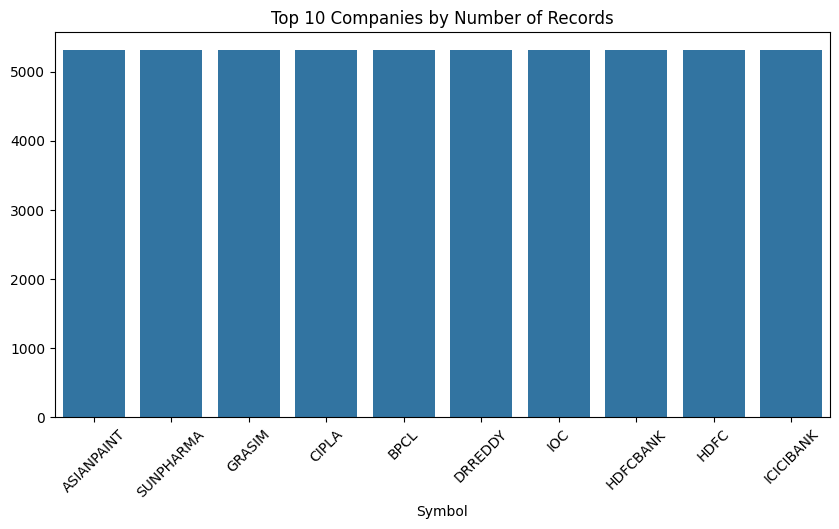

In [15]:
top_companies = df['Symbol'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_companies.index,
    y=top_companies.values
)

plt.title("Top 10 Companies by Number of Records")
plt.xticks(rotation=45)

plt.show()

In [16]:
avg_close = (
    df.groupby('Symbol')['Close']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

avg_close

,Close
Symbol,
NESTLEIND,7512.039647
EICHERMOT,6751.063167
SHREECEM,6565.809539
INFOSYSTCH,3323.156028
MARUTI,2925.005094
BAJAJFINSV,2758.657451
HEROMOTOCO,2665.182060
BAJFINANCE,2627.858937
BAJAJ-AUTO,2190.412196


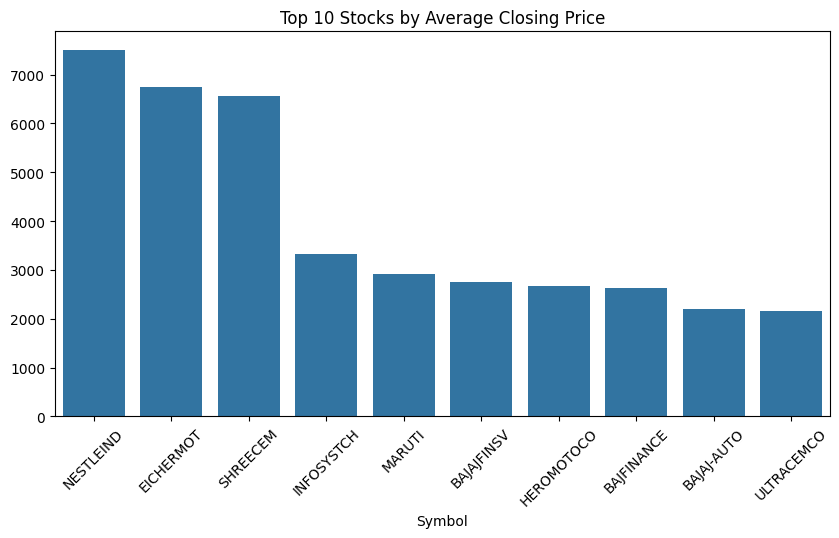

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=avg_close.index,
    y=avg_close.values
)

plt.title("Top 10 Stocks by Average Closing Price")

plt.xticks(rotation=45)

plt.show()

### Average Closing Price Analysis

The average closing price provides an overview of the typical trading range of a stock during the observed period.

Among the companies analyzed, NESTLEIND, EICHERMOT, and SHREECEM exhibited the highest average closing prices. These stocks consistently traded at premium price levels compared to other companies in the dataset.

It is important to note that a higher stock price does not necessarily indicate better investment performance. Stock prices are influenced by factors such as the number of shares outstanding, stock splits, and company-specific characteristics. Therefore, average price should be interpreted alongside return and risk metrics.


In [18]:
returns = []

for stock in df['Symbol'].unique():

    stock_df = df[df['Symbol'] == stock]

    first_price = stock_df['Close'].iloc[0]
    last_price = stock_df['Close'].iloc[-1]

    total_return = (
        (last_price - first_price)
        / first_price
    ) * 100

    returns.append(
        [stock, total_return]
    )

returns_df = pd.DataFrame(
    returns,
    columns=['Stock', 'Return (%)']
)

returns_df.sort_values(
    'Return (%)',
    ascending=False
).head(10)

,Stock,Return (%)
47,SHREECEM,43005.019305
14,EICHERMOT,4857.318321
38,MARUTI,3829.184419
27,INDUSINDBK,3129.533679
57,ULTRACEMCO,2313.124520
60,UTIBANK,2137.827715
4,BAJAJFINSV,2068.856806
5,BAJAUTOFIN,1463.743842
25,HINDUNILVR,1089.964611
34,KOTAKBANK,1026.804124


### Historical Return Analysis

To evaluate long-term investment performance, total percentage return was calculated for each company using the first and last available closing prices.

The analysis reveals that SHREECEM generated the highest historical return, followed by EICHERMOT and MARUTI.

These results indicate that certain companies delivered exceptional long-term value creation for investors. Historical return analysis provides useful insights into wealth generation potential and helps identify companies with strong long-term growth trajectories.

However, historical performance alone should not be used for investment decisions. Risk metrics and future market behavior must also be considered.


# Feature Engineering

In [19]:
df['Daily_Return'] = (
    df.groupby('Symbol')['Close']
      .pct_change()
)

In [20]:
df[['Symbol','Date','Close','Daily_Return']].head()

,Symbol,Date,Close,Daily_Return
1023,ADANIPORTS,2012-01-17,140.00,NaN
1024,ADANIPORTS,2012-01-18,141.70,0.012143
1025,ADANIPORTS,2012-01-19,149.40,0.054340
1026,ADANIPORTS,2012-01-20,155.40,0.040161
1027,ADANIPORTS,2012-01-23,146.75,-0.055663



Daily return measures the percentage change in stock price from one trading day to the next.



Daily returns are preferred over raw prices because they allow meaningful comparisons between companies with different stock price ranges.


In [21]:
# Simple Moving Average 20 (SMA20)
df['SMA20'] = (
    df.groupby('Symbol')['Close']
      .transform(lambda x: x.rolling(window=20).mean())
)

In [22]:
df[['Symbol','Date','Close','SMA20']].head(25)

,Symbol,Date,Close,SMA20
1023,ADANIPORTS,2012-01-17,140.00,NaN
1024,ADANIPORTS,2012-01-18,141.70,NaN
1025,ADANIPORTS,2012-01-19,149.40,NaN
1026,ADANIPORTS,2012-01-20,155.40,NaN
1027,ADANIPORTS,2012-01-23,146.75,NaN
1028,ADANIPORTS,2012-01-24,150.05,NaN
1029,ADANIPORTS,2012-01-25,143.20,NaN
1030,ADANIPORTS,2012-01-27,147.10,NaN
1031,ADANIPORTS,2012-01-30,138.40,NaN
1032,ADANIPORTS,2012-01-31,146.25,NaN


A Simple Moving Average (SMA) is a trend-following indicator that calculates the average closing price over a fixed number of trading days.

In this project, a 20-day moving average (SMA20) is computed for each stock. The indicator smooths short-term price fluctuations and helps identify underlying market trends.

Investors often compare the current stock price with its moving average to determine whether the stock is in an upward or downward trend.

The SMA20 will later be used as a feature for stock prediction, portfolio analysis, and investment recommendation generation.


In [23]:
# Exponentially moving average 20 (EMA20)
df['EMA20'] = (
    df.groupby('Symbol')['Close']
      .transform(lambda x: x.ewm(span=20,adjust=False).mean())
)

In [24]:
adani = df[df['Symbol'] == 'ADANIPORTS']

adani[['Date','Close','SMA20','EMA20']].head(25)

,Date,Close,SMA20,EMA20
1023,2012-01-17,140.00,NaN,140.000000
1024,2012-01-18,141.70,NaN,140.161905
1025,2012-01-19,149.40,NaN,141.041723
1026,2012-01-20,155.40,NaN,142.409178
1027,2012-01-23,146.75,NaN,142.822590
1028,2012-01-24,150.05,NaN,143.510915
1029,2012-01-25,143.20,NaN,143.481304
1030,2012-01-27,147.10,NaN,143.825941
1031,2012-01-30,138.40,NaN,143.309185
1032,2012-01-31,146.25,NaN,143.589263



The Exponential Moving Average (EMA) is a trend-following indicator that places greater weight on recent price observations.

Unlike the Simple Moving Average (SMA), which treats all observations equally, EMA responds more quickly to recent market movements and changing trends.

In this project, a 20-day EMA (EMA20) is calculated for each stock and used as an important feature for trend identification, stock movement prediction, and investment recommendation generation.



In [25]:
# Relative Strength Indicator (RSI)
from ta.momentum import RSIIndicator

df['RSI'] = (
    df.groupby('Symbol')['Close']
      .transform(
          lambda x: RSIIndicator(
              close=x,
              window=14
          ).rsi()
      )
)

In [26]:
adani = df[df['Symbol'] == 'ADANIPORTS']

adani[['Date','Close','RSI']].head(25)

,Date,Close,RSI
1023,2012-01-17,140.00,NaN
1024,2012-01-18,141.70,NaN
1025,2012-01-19,149.40,NaN
1026,2012-01-20,155.40,NaN
1027,2012-01-23,146.75,NaN
1028,2012-01-24,150.05,NaN
1029,2012-01-25,143.20,NaN
1030,2012-01-27,147.10,NaN
1031,2012-01-30,138.40,NaN
1032,2012-01-31,146.25,NaN



The Relative Strength Index (RSI) is a momentum indicator used to measure the speed and magnitude of recent price movements.

RSI values range from 0 to 100 and are commonly used to identify potentially overbought or oversold market conditions.

RSI > 70 may indicate that a stock is overbought.
RSI < 30 may indicate that a stock is oversold.
RSI values around 50 generally indicate neutral market conditions.

In this project, RSI is used as a predictive feature for stock movement forecasting and investment recommendation generation.

In [27]:
# Moving Average Convergence Divergence (MACD)
from ta.trend import MACD

df['MACD']=df.groupby('Symbol')['Close'].transform(lambda x: MACD(x).macd())

In [28]:
adani=df[df['Symbol']=='ADANIPORTS']
adani[['Date','Close','MACD']].tail()

,Date,Close,MACD
3317,2021-04-26,730.75,7.641067
3318,2021-04-27,749.15,7.737472
3319,2021-04-28,746.25,7.493488
3320,2021-04-29,746.75,7.256822
3321,2021-04-30,730.05,5.656508


MACD is a trend-following momentum indicator that measures the relationship between short-term and long-term exponential moving averages.

The indicator helps identify trend direction, momentum strength, and potential market reversals.

Positive MACD values generally indicate bullish market momentum, while negative values may indicate bearish momentum.

In this project, MACD is used as an additional feature for stock movement prediction and investment recommendation generation.

In [29]:
# Bollinger Bands
from ta.volatility import BollingerBands

bb=df.groupby('Symbol')['Close'].transform(lambda x:BollingerBands(x,window=20).bollinger_hband())
df['BB_High']=bb

df['BB_Low']=df.groupby('Symbol')['Close'].transform(lambda x:BollingerBands(x,window=20).bollinger_lband())

In [30]:
adani=df[df['Symbol']=='ADANIPORTS']
adani[['Close','BB_High','BB_Low']].tail()

,Close,BB_High,BB_Low
3317,730.75,831.194201,659.140799
3318,749.15,831.497857,663.067143
3319,746.25,829.943595,670.421405
3320,746.75,829.184147,675.550853
3321,730.05,828.488147,678.196853




Bollinger Bands are a volatility indicator used to measure the relative price level and market volatility of a stock.

The indicator consists of three lines:

* Middle Band: 20-day Simple Moving Average (SMA)
* Upper Band: SMA + 2 Standard Deviations
* Lower Band: SMA - 2 Standard Deviations

Bollinger Bands expand during periods of high volatility and contract during periods of low volatility.

Investors often use Bollinger Bands to identify potential overbought and oversold conditions:

* When the stock price approaches the Upper Band, it may indicate overbought conditions.
* When the stock price approaches the Lower Band, it may indicate oversold conditions.

In this project, Bollinger Bands are used as volatility-based features for stock movement prediction, risk assessment, and investment recommendation generation.


In [31]:
df[['Daily_Return','SMA20','EMA20','RSI','MACD','BB_High','BB_Low']].isnull().sum()

,0
Daily_Return,65
SMA20,1235
EMA20,0
RSI,845
MACD,1625
BB_High,1235
BB_Low,1235


# Modeling Approach

A supervised machine learning approach is used to predict future stock movement. Rather than predicting the exact future stock price, we are predicting the direction of price movement, which is often more practical for investment decision-making.

The dataset is divided into training and testing sets using a chronological split to preserve the temporal nature of financial data. Historical observations are used to train the model, while more recent observations are reserved for evaluation.

A Random Forest Classifier is selected as the baseline model due to its robustness, ability to capture non-linear relationships, and effectiveness when working with engineered financial features.

Model performance will be evaluated using classification metrics such as Accuracy, Precision, Recall, and F1-Score. These metrics help assess how effectively the model predicts future market direction.


In [32]:
df['Target']=df.groupby('Symbol')['Close'].shift(-1)>df['Close']
df['Target']=df['Target'].astype(int)

In [33]:
df[['Symbol','Date','Close','Target']].head(10)

,Symbol,Date,Close,Target
1023,ADANIPORTS,2012-01-17,140.00,1
1024,ADANIPORTS,2012-01-18,141.70,1
1025,ADANIPORTS,2012-01-19,149.40,1
1026,ADANIPORTS,2012-01-20,155.40,0
1027,ADANIPORTS,2012-01-23,146.75,1
1028,ADANIPORTS,2012-01-24,150.05,0
1029,ADANIPORTS,2012-01-25,143.20,1
1030,ADANIPORTS,2012-01-27,147.10,0
1031,ADANIPORTS,2012-01-30,138.40,1
1032,ADANIPORTS,2012-01-31,146.25,0


To formulate the stock prediction problem as a binary classification task, a target variable was created based on future price movement.

For each trading day:

Target = 1 if the next day's closing price is higher than the current day's closing price.
Target = 0 otherwise.

This approach focuses on predicting the direction of future stock movement rather than forecasting the exact price. Directional prediction is often more useful for practical investment decision-making and portfolio management

In [34]:
features=['Open','High','Low','Close','Volume',
          'Daily_Return','SMA20','EMA20',
          'RSI','MACD','BB_High','BB_Low']

In [35]:
model_df=df.dropna().copy()

In [36]:
model_df.shape

(233567, 20)

In [37]:
X=model_df[features]
y=model_df['Target']

In [38]:
# Train test split
split=int(len(model_df)*0.8)

X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [40]:
pred=rf.predict(X_test)

In [41]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,pred)

0.5060581410283855

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.50      0.51      0.51     23077
           1       0.51      0.50      0.51     23637

    accuracy                           0.51     46714
   macro avg       0.51      0.51      0.51     46714
weighted avg       0.51      0.51      0.51     46714



In [43]:
imp=pd.DataFrame({
    'Feature':features,
    'Importance':rf.feature_importances_
}).sort_values('Importance',ascending=False)

imp

,Feature,Importance
4,Volume,0.100481
5,Daily_Return,0.099955
8,RSI,0.096988
9,MACD,0.096693
11,BB_Low,0.081750
10,BB_High,0.080589
6,SMA20,0.075825
7,EMA20,0.074610
2,Low,0.073656
1,High,0.073344


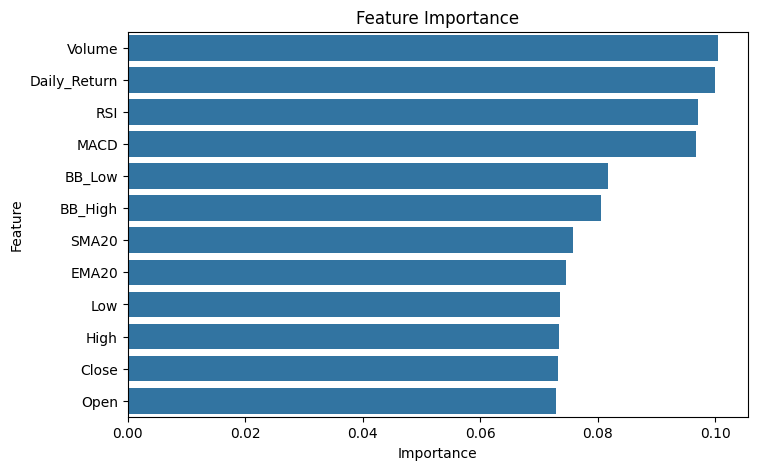

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(data=imp,x='Importance',y='Feature')
plt.title('Feature Importance')
plt.show()

### Random Forest Model Evaluation

The Random Forest Classifier achieved an overall accuracy of approximately 50.6% on the test dataset.

The classification report indicates that the model performed similarly across both classes, with Precision, Recall, and F1-Scores close to 0.50. While the model was able to identify some patterns within the historical market data, its predictive performance remained only marginally better than random guessing.

To address these limitations, the project adopts XGBoost (Extreme Gradient Boosting), a state-of-the-art boosting algorithm that sequentially builds trees, with each new tree focusing on correcting the errors of previous trees.

In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report

xgb=XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train,y_train)

pred=xgb.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

Accuracy: 0.5101468510510767
              precision    recall  f1-score   support

           0       0.51      0.42      0.46     23077
           1       0.51      0.60      0.55     23637

    accuracy                           0.51     46714
   macro avg       0.51      0.51      0.51     46714
weighted avg       0.51      0.51      0.51     46714



# Improving the Prediction Framework

The initial prediction model was designed to forecast whether the next day's stock price would move upward or downward. Although both Random Forest and XGBoost were able to learn certain patterns from the data, their predictive performance remained close to random guessing.

One possible reason is that daily stock price movements often contain significant market noise. Very small price changes, such as a gain or loss of a few basis points, may not represent meaningful investment opportunities and can make the prediction task unnecessarily difficult.

To address this limitation, the prediction framework is refined to focus on **significant market movements** rather than minor day-to-day fluctuations.

Instead of predicting every small price change, the model will identify:

* Significant Positive Movements (future return greater than 1%)
* Significant Negative Movements (future return less than -1%)

Observations with very small future returns are excluded because they provide limited actionable value to investors.

This modification transforms the prediction task from forecasting noisy short-term fluctuations to identifying potentially meaningful investment opportunities. The resulting predictions are expected to be more relevant for decision support and portfolio management.

# Enhanced Feature Engineering

In addition to refining the target variable, several new market indicators are introduced to provide the model with richer information about stock behavior.

The newly engineered features include:

### Price Range

Measures the daily trading range relative to the closing price and captures intraday volatility.

### Gap

Measures the difference between the opening price and the previous day's closing price, helping identify overnight market sentiment.

### Rolling Volatility

Calculates the 20-day standard deviation of daily returns and serves as a measure of historical risk.

### Volume Change

Measures changes in trading activity relative to the previous day and can indicate unusual market participation.

These additional features are intended to capture market dynamics that may not be fully represented by traditional technical indicators alone.

By combining a more meaningful prediction target with richer market features, the upgraded framework aims to improve predictive performance and generate more actionable investment intelligence.


In [46]:
import numpy as np

df['Future_Return']=df.groupby('Symbol')['Close'].pct_change().shift(-1)

In [47]:
df['Target_new']=np.where(df['Future_Return']>0.01,1,
               np.where(df['Future_Return']<-0.01,0,np.nan))

In [48]:
df['Price_Range']=(df['High']-df['Low'])/df['Close']

In [49]:
df['Gap']=(df['Open']-df['Prev Close'])/df['Prev Close']

In [50]:
df['Volatility20']=df.groupby('Symbol')['Daily_Return'].transform(lambda x:x.rolling(20).std())

In [51]:
df['Volume_Change']=df.groupby('Symbol')['Volume'].pct_change()

In [52]:
features_new=['Open','High','Low','Close','Volume',
          'Daily_Return','SMA20','EMA20','RSI','MACD',
          'BB_High','BB_Low',
          'Price_Range','Gap',
          'Volatility20','Volume_Change']

In [53]:
model_df=df.dropna().copy()

In [54]:
X_new=model_df[features_new]
y_new=model_df['Target_new']

In [55]:
# Train test split
split=int(len(model_df)*0.8)

X_train_new,X_test_new=X[:split],X[split:]
y_train_new,y_test_new=y[:split],y[split:]

In [56]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report

xgb=XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_new,y_train_new)

pred_new=xgb.predict(X_test_new)

print("Accuracy:",accuracy_score(y_test_new,pred_new))
print(classification_report(y_test_new,pred_new))

Accuracy: 0.5063850725384219
              precision    recall  f1-score   support

           0       0.50      0.46      0.48     64350
           1       0.51      0.55      0.53     65719

    accuracy                           0.51    130069
   macro avg       0.51      0.51      0.50    130069
weighted avg       0.51      0.51      0.51    130069



# Prediction Model Findings

Multiple machine learning approaches were evaluated for stock movement prediction, including Random Forest and XGBoost classifiers. Additional feature engineering techniques and alternative target formulations were also explored to improve predictive performance.

Despite these enhancements, the predictive accuracy remained close to 50%, indicating that short-term stock price movements are highly complex and difficult to predict using historical price and volume information alone.

This observation is consistent with financial market theory, where market prices often incorporate available information efficiently, limiting the predictive power of purely historical technical indicators.

The experiments demonstrate that while machine learning models can identify certain market patterns, reliable short-term forecasting remains a challenging task. Consequently, the project places greater emphasis on investment intelligence, risk assessment, portfolio construction, and explainable analytics rather than relying solely on directional price prediction.


# Regression-Based Stock Forecasting

In addition to predicting the direction of future stock movements, a regression-based forecasting approach is explored to estimate future market behavior quantitatively.

The earlier classification models focused on determining whether a stock's price would move upward or downward on the next trading day. While this approach provides directional insights, it does not indicate the magnitude of the expected movement.

To obtain a more detailed understanding of future stock performance, a regression model is developed to predict future returns based on historical market data and technical indicators.

In [57]:
df['Future_Return']=df.groupby('Symbol')['Close'].pct_change().shift(-1)

In [58]:
reg_df=df.dropna().copy()

In [59]:
features=['Open','High','Low','Close','Volume',
          'Daily_Return','SMA20','EMA20',
          'RSI','MACD','BB_High','BB_Low']

In [60]:
X=reg_df[features]
y=reg_df['Future_Return']

In [61]:
split=int(len(reg_df)*0.8)

X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

In [62]:
from sklearn.ensemble import RandomForestRegressor

rf_reg=RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_reg.fit(X_train,y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [63]:
pred=rf_reg.predict(X_test)

In [64]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np

mae=mean_absolute_error(y_test,pred)
rmse=np.sqrt(mean_squared_error(y_test,pred))
r2=r2_score(y_test,pred)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 0.028317588044431418
RMSE: 0.03814316138538298
R2: -0.027332506400965517


# Regression Model Results and Analysis

The Random Forest Regressor achieved a Mean Absolute Error (MAE) of 0.0283, a Root Mean Squared Error (RMSE) of 0.0381, and an R² Score of -0.0273.

The results indicate that predicting short-term stock returns using only historical price, volume, and technical indicators is a challenging task. Although the model is capable of capturing certain market patterns, its overall explanatory power remains limited, as reflected by the negative R² Score.

This observation is consistent with the inherently complex and noisy nature of financial markets, where future price movements are influenced by numerous external factors that are not present in the provided dataset.

The findings suggest that while predictive models can provide supplementary insights, investment decisions should not rely solely on short-term forecasting. Consequently, the project emphasizes risk assessment, portfolio construction, and explainable investment analytics as core components of the investment intelligence platform.


# Risk Assessment Module

The module calculates multiple risk metrics that capture different dimensions of investment risk and performance:

* Volatility
* Sharpe Ratio
* Sortino Ratio
* Maximum Drawdown
* Composite Risk Score

The resulting risk analytics form the foundation for portfolio construction and investment recommendation generation.


In [65]:
# Annualized Volatility
volatility=df.groupby('Symbol')['Daily_Return'].std()*np.sqrt(252)

Volatility measures how much a stock's returns fluctuate.

Higher volatility = Higher risk.

In [66]:
# Sharpe Ratio
sharpe=(df.groupby('Symbol')['Daily_Return'].mean()*252)/(df.groupby('Symbol')['Daily_Return'].std()*np.sqrt(252))

It measures return earned per unit of risk

Higher is better

In [67]:
# Sortino Ratio (Similar to Sharpe, but only penalizes downside risk.)
downside=df['Daily_Return'].where(df['Daily_Return']<0)

sortino=(df.groupby('Symbol')['Daily_Return'].mean()*252)/(downside.groupby(df['Symbol']).std()*np.sqrt(252))

In [68]:
# Maximum Drawdown (It answers what was the biggest historical loss)
def max_drawdown(x):
    cum=(1+x).cumprod()
    peak=cum.cummax()
    dd=(cum-peak)/peak
    return dd.min()

In [69]:
mdd=df.groupby('Symbol')['Daily_Return'].apply(max_drawdown)

In [70]:
risk_df=pd.DataFrame({
    'Volatility':volatility,
    'Sharpe_Ratio':sharpe,
    'Sortino_Ratio':sortino,
    'Max_Drawdown':mdd
}).reset_index()
risk_df.head()

,Symbol,Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown
0,ADANIPORTS,0.381750,0.665632,0.978817,-0.536936
1,ASIANPAINT,0.354875,0.571252,0.551031,-0.924805
2,AXISBANK,0.475803,0.353750,0.400789,-0.850174
3,BAJAJ-AUTO,0.338834,0.615186,0.717233,-0.599151
4,BAJAJFINSV,0.400940,0.805978,1.133433,-0.867894


| Volatility | Meaning                     |
| ---------- | --------------------------- |   
| < 20%      | Low Risk / Stable Stock     |
| 20% - 40%  | Moderate Risk               |
| > 40%      | High Risk / Highly Volatile |

<br>

| Sharpe Ratio | Meaning          |
| ------------ | ---------------- |
| < 0          | Poor Performance |
| 0 - 1        | Acceptable       |
| 1 - 2        | Good             |
| > 2          | Excellent        |

<br>

| Sortino Ratio | Meaning          |
| ------------- | ---------------- |
| < 0           | Poor Performance |
| 0 - 1         | Moderate         |
| 1 - 2         | Good             |
| > 2           | Excellent        |

<br>

| Maximum Drawdown | Meaning       |
| ---------------- | ------------- |
| 0% to -20%       | Low Risk      |
| -20% to -50%     | Moderate Risk |
| Below -50%       | High Risk     |


# Composite Risk Score

While individual risk metrics provide valuable insights, investors often require a single measure that summarizes overall risk.

To facilitate stock ranking and portfolio construction, a Composite Risk Score is developed by combining multiple risk indicators:

* Annualized Volatility
* Sharpe Ratio
* Sortino Ratio
* Maximum Drawdown

All metrics are normalized to a common scale before aggregation.

The scoring framework rewards stocks with:

* Lower volatility
* Lower drawdowns
* Higher Sharpe ratios
* Higher Sortino ratios

A lower Risk Score indicates a relatively safer investment profile, while a higher Risk Score suggests greater historical risk exposure.

The Composite Risk Score serves as the primary ranking mechanism for identifying suitable stocks for conservative, balanced, and aggressive investment portfolios.


In [71]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()

risk_df[['Vol_N','Sharpe_N','Sortino_N','MDD_N']]=scaler.fit_transform(
    risk_df[['Volatility','Sharpe_Ratio','Sortino_Ratio','Max_Drawdown']]
)

In [72]:
risk_df['Risk_Score']=(
    risk_df['Vol_N']
    +(1-risk_df['Sharpe_N'])
    +(1-risk_df['Sortino_N'])
    +risk_df['MDD_N']
)/4*100

To create a unified measure of investment risk, all risk metrics were normalized and combined using equal weighting. Equal weights were selected to ensure that no single risk indicator disproportionately influenced the final score.

In [73]:
risk_df=risk_df.sort_values('Risk_Score')
risk_df[['Symbol','Risk_Score']].head(10)

,Symbol,Risk_Score
47,SHREECEM,20.017394
4,BAJAJFINSV,21.770257
57,ULTRACEMCO,22.385411
1,ASIANPAINT,22.866671
6,BAJFINANCE,23.669498
7,BHARTI,24.365395
5,BAJAUTOFIN,24.443875
14,EICHERMOT,24.728389
10,BRITANNIA,26.062391
56,TITAN,26.401571


### Historical Return Analysis

While risk metrics provide insights into the stability and downside exposure of a stock, investors are also interested in historical performance.

Therefore, cumulative historical returns are calculated for each company. These returns help evaluate how much wealth an investor would have generated over the available historical period.

By combining return analysis with risk assessment metrics, the portfolio construction framework can recommend investments that align with different investor preferences and risk tolerances.


In [74]:
returns=df.groupby('Symbol')['Close'].apply(lambda x:(x.iloc[-1]-x.iloc[0])/x.iloc[0]*100).reset_index(name='Total_Return')

In [75]:
portfolio_df=risk_df.merge(returns,on='Symbol')

In [76]:
portfolio_df[['Symbol','Total_Return']].sort_values('Total_Return',ascending=False).head(10)

,Symbol,Total_Return
0,SHREECEM,43005.019305
7,EICHERMOT,4857.318321
14,MARUTI,3829.184419
28,INDUSINDBK,3129.533679
2,ULTRACEMCO,2313.124520
29,UTIBANK,2137.827715
1,BAJAJFINSV,2068.856806
6,BAJAUTOFIN,1463.743842
52,HINDUNILVR,1089.964611
30,KOTAKBANK,1026.804124


# Portfolio Construction Module

# Portfolio Construction Methodology

The portfolios are constructed using a combination of historical return performance and risk metrics, including:

- Volatility
- Sharpe Ratio
- Sortino Ratio
- Maximum Drawdown
- Historical Total Return

---

## 1. Conservative Portfolio

The Conservative Portfolio is designed for risk-averse investors whose primary objective is capital preservation and stable long-term growth.

### Selection Criteria

Stocks are selected if they satisfy the following conditions:

- Volatility below the median volatility of all stocks
- Sharpe Ratio above the median Sharpe Ratio
- Sortino Ratio above the median Sortino Ratio
- Maximum Drawdown better than the median drawdown

---

## 2. Balanced Portfolio

The Balanced Portfolio is intended for investors seeking a balance between risk and return.

### Selection Criteria

Stocks are selected if they satisfy:

- Historical Return above the median return
- Sharpe Ratio above the median Sharpe Ratio
- Volatility below the 75th percentile
- Acceptable Maximum Drawdown levels

---

## 3. Aggressive Portfolio

The Aggressive Portfolio is designed for investors focused primarily on maximizing long-term capital appreciation.

### Selection Criteria

Stocks are ranked according to their historical cumulative returns.

The top-performing stocks are selected, optionally filtering out companies with negative Sharpe Ratios to avoid extremely poor risk-adjusted performers.

---

### Portfolio Design Philosophy

The three-portfolio framework enables the investment intelligence platform to provide personalized recommendations for different investor types.

- Conservative investors prioritize safety and stability.
- Balanced investors seek a compromise between growth and risk.
- Aggressive investors prioritize maximum return potential.

By combining historical performance with multiple risk metrics, the portfolio construction process remains transparent, explainable, and aligned with the principles of data-driven investment decision making.

In [77]:
conservative=portfolio_df[
    (portfolio_df['Volatility']<portfolio_df['Volatility'].median()) &
    (portfolio_df['Sharpe_Ratio']>portfolio_df['Sharpe_Ratio'].median()) &
    (portfolio_df['Sortino_Ratio']>portfolio_df['Sortino_Ratio'].median()) &
    (portfolio_df['Max_Drawdown']>portfolio_df['Max_Drawdown'].median())
].sort_values('Sharpe_Ratio',ascending=False)

In [78]:
balanced = portfolio_df[
    (portfolio_df['Total_Return'] > portfolio_df['Total_Return'].median()) &
    (portfolio_df['Sharpe_Ratio'] > portfolio_df['Sharpe_Ratio'].median()) &
    (portfolio_df['Volatility'] < portfolio_df['Volatility'].quantile(0.75))
]

In [79]:
aggressive = portfolio_df[
    portfolio_df['Sharpe_Ratio'] > 0
].sort_values('Total_Return', ascending=False).head(10)

In [80]:
df.columns

Index(['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last',
       'Close', 'VWAP', 'Volume', 'Turnover', 'Daily_Return', 'SMA20', 'EMA20',
       'RSI', 'MACD', 'BB_High', 'BB_Low', 'Target', 'Future_Return',
       'Target_new', 'Price_Range', 'Gap', 'Volatility20', 'Volume_Change'],
      dtype='object')

In [81]:
risk_df.head()

,Symbol,Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Vol_N,Sharpe_N,Sortino_N,MDD_N,Risk_Score
47,SHREECEM,0.389665,0.981088,1.538228,-0.799734,0.256069,0.881141,0.833093,0.258861,20.017394
4,BAJAJFINSV,0.400940,0.805978,1.133433,-0.867894,0.275655,0.818464,0.750273,0.163892,21.770257
57,ULTRACEMCO,0.332647,0.748410,1.147592,-0.777797,0.157018,0.797859,0.753170,0.289427,22.385411
1,ASIANPAINT,0.354875,0.571252,0.551031,-0.924805,0.195633,0.734449,0.631114,0.084597,22.866671
6,BAJFINANCE,0.466824,0.837678,0.823926,-0.932820,0.390109,0.829810,0.686948,0.073429,23.669498


In [82]:
portfolio_df.head()

,Symbol,Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Vol_N,Sharpe_N,Sortino_N,MDD_N,Risk_Score,Total_Return
0,SHREECEM,0.389665,0.981088,1.538228,-0.799734,0.256069,0.881141,0.833093,0.258861,20.017394,43005.019305
1,BAJAJFINSV,0.400940,0.805978,1.133433,-0.867894,0.275655,0.818464,0.750273,0.163892,21.770257,2068.856806
2,ULTRACEMCO,0.332647,0.748410,1.147592,-0.777797,0.157018,0.797859,0.753170,0.289427,22.385411,2313.124520
3,ASIANPAINT,0.354875,0.571252,0.551031,-0.924805,0.195633,0.734449,0.631114,0.084597,22.866671,564.587973
4,BAJFINANCE,0.466824,0.837678,0.823926,-0.932820,0.390109,0.829810,0.686948,0.073429,23.669498,603.834237


# Investment Intelligence Insights

To support data-driven investment decisions, key market insights were generated from the historical NIFTY-50 dataset.

The analysis identifies:

- Top-performing stocks based on cumulative returns
- Stocks exhibiting the lowest volatility
- Stocks with the strongest risk-adjusted performance
- Stocks with superior downside-risk characteristics
- Stocks demonstrating resilience during market downturns

These insights help investors quickly identify potential investment opportunities and understand the historical behavior of different companies.

In [83]:
# Top 10 Performing Stocks
portfolio_df[['Symbol','Total_Return']].sort_values(
    'Total_Return',ascending=False
).head(10)

,Symbol,Total_Return
0,SHREECEM,43005.019305
7,EICHERMOT,4857.318321
14,MARUTI,3829.184419
28,INDUSINDBK,3129.533679
2,ULTRACEMCO,2313.124520
29,UTIBANK,2137.827715
1,BAJAJFINSV,2068.856806
6,BAJAUTOFIN,1463.743842
52,HINDUNILVR,1089.964611
30,KOTAKBANK,1026.804124


In [84]:
# Lowest Volatility Stocks
risk_df[['Symbol','Volatility']].sort_values(
    'Volatility'
).head(10)

,Symbol,Volatility
40,NESTLEIND,0.242261
25,HINDUNILVR,0.267452
21,HEROMOTOCO,0.287149
43,POWERGRID,0.297119
12,COALINDIA,0.298262
41,NTPC,0.301924
57,ULTRACEMCO,0.332647
10,BRITANNIA,0.335686
3,BAJAJ-AUTO,0.338834
33,JSWSTL,0.343096


In [85]:
# Highest Sharpe Ratio Stocks
risk_df[['Symbol','Sharpe_Ratio']].sort_values(
    'Sharpe_Ratio',ascending=False
).head(10)

,Symbol,Sharpe_Ratio
7,BHARTI,1.313163
60,UTIBANK,1.067778
47,SHREECEM,0.981088
6,BAJFINANCE,0.837678
40,NESTLEIND,0.817072
25,HINDUNILVR,0.816709
4,BAJAJFINSV,0.805978
38,MARUTI,0.778495
5,BAJAUTOFIN,0.773402
57,ULTRACEMCO,0.748410


In [86]:
# Highest Sortino Ratio Stocks
risk_df[['Symbol','Sortino_Ratio']].sort_values(
    'Sortino_Ratio',ascending=False
).head(10)

,Symbol,Sortino_Ratio
7,BHARTI,2.354002
60,UTIBANK,1.705966
47,SHREECEM,1.538228
25,HINDUNILVR,1.310191
40,NESTLEIND,1.279066
5,BAJAUTOFIN,1.216965
38,MARUTI,1.156920
57,ULTRACEMCO,1.147592
4,BAJAJFINSV,1.133433
0,ADANIPORTS,0.978817


In [87]:
# Lowest Drawdown Stocks
risk_df[['Symbol','Max_Drawdown']].sort_values(
    'Max_Drawdown',ascending=False
).head(10)

,Symbol,Max_Drawdown
25,HINDUNILVR,-0.267812
40,NESTLEIND,-0.324011
33,JSWSTL,-0.364321
48,SSLT,-0.410175
0,ADANIPORTS,-0.536936
7,BHARTI,-0.541943
60,UTIBANK,-0.590194
3,BAJAJ-AUTO,-0.599151
38,MARUTI,-0.613397
21,HEROMOTOCO,-0.616320


In [88]:
# Best Conservative Stocks
conservative.head(5)

,Symbol,Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Vol_N,Sharpe_N,Sortino_N,MDD_N,Risk_Score,Total_Return
0,SHREECEM,0.389665,0.981088,1.538228,-0.799734,0.256069,0.881141,0.833093,0.258861,20.017394,43005.019305
44,NESTLEIND,0.242261,0.817072,1.279066,-0.324011,0.000000,0.822435,0.780069,0.921698,32.979841,553.769066
52,HINDUNILVR,0.267452,0.816709,1.310191,-0.267812,0.043762,0.822305,0.786437,1.000000,35.875484,1089.964611
14,MARUTI,0.344806,0.778495,1.156920,-0.613397,0.178141,0.808627,0.755078,0.518489,28.323120,3829.184419
2,ULTRACEMCO,0.332647,0.748410,1.147592,-0.777797,0.157018,0.797859,0.753170,0.289427,22.385411,2313.124520


In [89]:
# Best Balanced Stocks
balanced.head(5)

,Symbol,Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Vol_N,Sharpe_N,Sortino_N,MDD_N,Risk_Score,Total_Return
0,SHREECEM,0.389665,0.981088,1.538228,-0.799734,0.256069,0.881141,0.833093,0.258861,20.017394,43005.019305
1,BAJAJFINSV,0.400940,0.805978,1.133433,-0.867894,0.275655,0.818464,0.750273,0.163892,21.770257,2068.856806
2,ULTRACEMCO,0.332647,0.748410,1.147592,-0.777797,0.157018,0.797859,0.753170,0.289427,22.385411,2313.124520
3,ASIANPAINT,0.354875,0.571252,0.551031,-0.924805,0.195633,0.734449,0.631114,0.084597,22.866671,564.587973
4,BAJFINANCE,0.466824,0.837678,0.823926,-0.932820,0.390109,0.829810,0.686948,0.073429,23.669498,603.834237


In [90]:
# Best Aggressive Stocks
aggressive.head(5)

,Symbol,Volatility,Sharpe_Ratio,Sortino_Ratio,Max_Drawdown,Vol_N,Sharpe_N,Sortino_N,MDD_N,Risk_Score,Total_Return
0,SHREECEM,0.389665,0.981088,1.538228,-0.799734,0.256069,0.881141,0.833093,0.258861,20.017394,43005.019305
7,EICHERMOT,0.480399,0.722399,0.896955,-0.938237,0.413692,0.788549,0.701890,0.065882,24.728389,4857.318321
14,MARUTI,0.344806,0.778495,1.156920,-0.613397,0.178141,0.808627,0.755078,0.518489,28.323120,3829.184419
28,INDUSINDBK,0.507056,0.607113,0.811043,-0.851066,0.460000,0.747285,0.684312,0.187339,30.393546,3129.533679
2,ULTRACEMCO,0.332647,0.748410,1.147592,-0.777797,0.157018,0.797859,0.753170,0.289427,22.385411,2313.124520


# Portfolio Allocation Methodology

After identifying stocks suitable for each investor profile, portfolio weights are assigned using profile-specific allocation strategies to top 10 companies.

## Conservative Portfolio

Weights are assigned using inverse volatility.

Weight ∝ 1 / Volatility

This approach allocates a larger proportion of capital to stocks that have historically exhibited lower price fluctuations, thereby reducing overall portfolio risk.

## Balanced Portfolio

Weights are assigned using a combination of Sharpe Ratio and Sortino Ratio.

Weight ∝ Sharpe Ratio + Sortino Ratio

This method favors stocks that have generated superior risk-adjusted returns while maintaining reasonable downside risk characteristics.

## Aggressive Portfolio

Weights are assigned based on the square root of historical cumulative returns.

Weight ∝ √(Historical Return)

The square-root transformation prevents excessive concentration in a single high-return stock while still emphasizing growth-oriented investments.

These allocation strategies ensure that each portfolio remains aligned with its intended investor profile and investment objective.

In [91]:
print(len(conservative))
print(len(balanced))
print(len(aggressive))

12
22
10


In [92]:
# Conservative Allocation
conservative = conservative.sort_values(
    'Sharpe_Ratio',
    ascending=False
).head(10)

In [93]:
conservative['Weight'] = (
    (1/conservative['Volatility']) /
    (1/conservative['Volatility']).sum()
)*100

In [94]:
# Balanced Allocation
balanced = balanced.sort_values(
    'Total_Return',
    ascending=False
).head(10)

In [95]:
balanced['Weight'] = (
    (balanced['Sharpe_Ratio'] + balanced['Sortino_Ratio']) /
    (balanced['Sharpe_Ratio'] + balanced['Sortino_Ratio']).sum()
)*100

In [96]:
# Aggressive Allocation
import numpy as np

aggressive['Weight'] = (
    np.sqrt(aggressive['Total_Return']) /
    np.sqrt(aggressive['Total_Return']).sum()
)*100

In [97]:
conservative[['Symbol','Weight']]

,Symbol,Weight
0,SHREECEM,8.710765
44,NESTLEIND,14.010840
52,HINDUNILVR,12.691176
14,MARUTI,9.844020
2,ULTRACEMCO,10.203843
13,UPL,8.515324
49,ADANIPORTS,8.891361
37,BAJAJ-AUTO,10.017528
11,HDFCBANK,8.920566
20,HDFC,8.194577


In [98]:
balanced[['Symbol','Weight']]

,Symbol,Weight
0,SHREECEM,13.613493
14,MARUTI,10.458301
2,ULTRACEMCO,10.245324
1,BAJAJFINSV,10.479893
52,HINDUNILVR,11.493012
30,KOTAKBANK,6.271759
11,HDFCBANK,5.802110
5,BHARTI,19.816061
20,HDFC,5.830813
16,ICICIBANK,5.989233


In [99]:
aggressive[['Symbol','Weight']]

,Symbol,Weight
0,SHREECEM,32.502770
7,EICHERMOT,10.923431
14,MARUTI,9.698709
28,INDUSINDBK,8.768001
2,ULTRACEMCO,7.538072
29,UTIBANK,7.246815
1,BAJAJFINSV,7.128957
6,BAJAUTOFIN,5.996438
52,HINDUNILVR,5.174483
30,KOTAKBANK,5.022323


In [100]:
conservative.to_csv('conservative_portfolio.csv',index=False)
balanced.to_csv('balanced_portfolio.csv',index=False)
aggressive.to_csv('aggressive_portfolio.csv',index=False)

In [101]:
risk_df.to_csv('risk_metrics.csv',index=False)

In [102]:
portfolio_df.to_csv('portfolio_metrics.csv',index=False)

In [105]:
def explain_stock(row):

    reasons=[]

    if row['Sharpe_Ratio']>risk_df['Sharpe_Ratio'].median():
        reasons.append("High Sharpe Ratio")

    if row['Sortino_Ratio']>risk_df['Sortino_Ratio'].median():
        reasons.append("High Sortino Ratio")

    if row['Volatility']<risk_df['Volatility'].median():
        reasons.append("Low Volatility")

    if row['Max_Drawdown']>risk_df['Max_Drawdown'].median():
        reasons.append("Lower Drawdown Risk")

    return ", ".join(reasons)

In [106]:
conservative['Justification']=conservative.apply(explain_stock,axis=1)

balanced['Justification']=balanced.apply(explain_stock,axis=1)

aggressive['Justification']=aggressive.apply(explain_stock,axis=1)

In [107]:
conservative[['Symbol','Weight','Justification']].head()

,Symbol,Weight,Justification
0,SHREECEM,8.710765,"High Sharpe Ratio, High Sortino Ratio, Low Vol..."
44,NESTLEIND,14.010840,"High Sharpe Ratio, High Sortino Ratio, Low Vol..."
52,HINDUNILVR,12.691176,"High Sharpe Ratio, High Sortino Ratio, Low Vol..."
14,MARUTI,9.844020,"High Sharpe Ratio, High Sortino Ratio, Low Vol..."
2,ULTRACEMCO,10.203843,"High Sharpe Ratio, High Sortino Ratio, Low Vol..."


# Conclusion

This project developed a comprehensive Investment Intelligence Platform using historical NIFTY-50 market data.

The system combines:

- Technical Indicator Analysis
- Stock Movement Prediction
- Risk Assessment
- Portfolio Construction
- Investment Insights
- Explainable Recommendations

Three investor-specific portfolios were generated:

- Conservative Portfolio
- Balanced Portfolio
- Aggressive Portfolio

Risk assessment was performed using Volatility, Sharpe Ratio, Sortino Ratio, and Maximum Drawdown.

The platform demonstrates how historical market data can be transformed into actionable investment intelligence that supports informed and transparent investment decision-making.